In [1]:
%pip install ax-platform matplotlib

  Using cached ax_platform-1.3.1-py3-none-any.whl.metadata (10 kB)
  Using cached botorch-0.18.1-py3-none-any.whl.metadata (10 kB)
  Using cached pyre_extensions-0.0.32-py3-none-any.whl.metadata (4.0 kB)
  Using cached markdown-3.10.2-py3-none-any.whl.metadata (5.1 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached gpytorch-1.15.2-py3-none-any.whl.metadata (8.2 kB)
  Using cached linear_operator-0.6.1-py3-none-any.whl.metadata (15 kB)
  Using cached torch-2.13.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (38 kB)
  Using cached multipledispatch-1.0.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pymoo-0.6.2-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached typing_inspect-0.9.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached filelock-3.29.7-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensio

[INFO 07-14 07:09:20] ax.storage.sqa_store.with_db_settings_base: Ax SQL storage initialized with SQLAlchemy 2.0.22
[INFO 07-14 07:09:21] ax.api.client: GenerationStrategy(name='Center+Sobol+MBM:fast', nodes=[CenterGenerationNode(next_node_name='Sobol', use_existing_trials_for_initialization=True), GenerationNode(name='Sobol', generator_specs=[GeneratorSpec(generator_enum=Sobol, generator_key_override=None)], transition_criteria=[MinTrials(transition_to='MBM'), MinTrials(transition_to='MBM')], suggested_experiment_status=ExperimentStatus.INITIALIZATION, pausing_criteria=[MaxTrialsAwaitingData(threshold=5)]), GenerationNode(name='MBM', generator_specs=[GeneratorSpec(generator_enum=BoTorch, generator_key_override=None)], transition_criteria=None, suggested_experiment_status=ExperimentStatus.OPTIMIZATION, pausing_criteria=None)]) chosen based on user input and problem structure.
[INFO 07-14 07:09:21] ax.api.client: Generated new trial 0 with parameters {'x': 1.0} using GenerationNode Cent

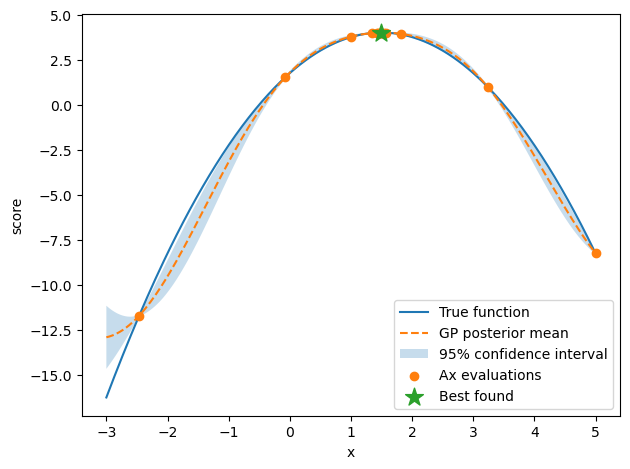

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from ax.api.client import Client
from ax.api.configs import RangeParameterConfig
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood


def objective(x): return -(x - 1.5) ** 2 + 4

client = Client()
client.configure_experiment(parameters=[
    RangeParameterConfig(name="x", parameter_type="float", bounds=(-3, 5))
])
client.configure_optimization(objective="score")


xs, ys = [], []
for _ in range(15):
    for trial_id, parameters in client.get_next_trials(max_trials=1).items():
        x, y = parameters["x"], objective(parameters["x"])
        xs.append(x)
        ys.append(y)
        client.complete_trial(trial_index=trial_id, raw_data={"score": y})

train_x = torch.tensor(xs).unsqueeze(-1)
train_y = torch.tensor(ys).unsqueeze(-1)

gp = SingleTaskGP(train_x, train_y)
fit_gpytorch_mll(ExactMarginalLogLikelihood(gp.likelihood, gp))

grid = torch.linspace(-3, 5, 300).unsqueeze(-1)
with torch.no_grad():
    posterior = gp.posterior(grid)
    mean = posterior.mean.squeeze()
    lower, upper = posterior.mvn.confidence_region()

x_plot = grid.squeeze().numpy()
plt.plot(x_plot, objective(x_plot), label="True function")
plt.plot(x_plot, mean.numpy(), "--", label="GP posterior mean")
plt.fill_between(x_plot, lower.numpy(), upper.numpy(), alpha=.25,
                 label="95% confidence interval")
plt.scatter(xs, ys, label="Ax evaluations", zorder=3)
best = np.argmax(ys)
plt.scatter(xs[best], ys[best], marker="*", s=180, label="Best found", zorder=4)
plt.xlabel("x"); plt.ylabel("score"); plt.legend(); plt.tight_layout(); plt.show()